*Aljoscha Rheinwalt <aljoscha.rheinwalt@uni-potsdam.de> (2026)*

---

# CUDA block matching of two Sentinel-2 rasters

This tutorial estimates a dense pixel displacement field from the 2018 image to the 2020 image with masked normalized cross-correlation (NCC), checks each match in the reverse direction, and writes georeferenced GeoTIFF products.

The matcher treats pixel value `0` as missing. It returns horizontal displacement `u` (columns, positive east/right) and vertical displacement `v` (rows, positive south/down), both in pixels. The value `-128` is nodata. Correlations are exhaustive over the search window, so the full raster with a block radius of 12 (a 25 × 25 window) and search radius of 40 is a substantial GPU job.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from numba import cuda
from osgeo import gdal

from block_matching import block_matching_masked_ncc_uint_nonzero_fb

gdal.UseExceptions()

DATA_DIR = Path.cwd()
REFERENCE = DATA_DIR / "Sentinel2_PAN_20180804.tif"
TARGET = DATA_DIR / "Sentinel2_PAN_20200823.tif"

RAW_OUTPUT_PATHS = {
    "u": DATA_DIR / "Sentinel2_u.tif",
    "v": DATA_DIR / "Sentinel2_v.tif",
    "cmax8": DATA_DIR / "Sentinel2_cmax8.tif",
    "cmean8": DATA_DIR / "Sentinel2_cmean8.tif",
    "cstd8": DATA_DIR / "Sentinel2_cstd8.tif",
    "sstd": DATA_DIR / "Sentinel2_sstd.tif",
    "tstd": DATA_DIR / "Sentinel2_tstd.tif",
    "efb2": DATA_DIR / "Sentinel2_efb2.tif",
}

## GeoTIFF writer

Every output copies the reference raster's transform and projection. Integer products use predictor 2 and floating-point products use predictor 3.

In [2]:
def writetiff(filename, data, reference=REFERENCE, nodata=None, compress=True):
    with gdal.Open(str(reference), gdal.GA_ReadOnly) as src:
        if data.ndim != 2:
            raise ValueError("data must be a 2-D array")

        expected_shape = (src.RasterYSize, src.RasterXSize)
        if data.shape != expected_shape:
            raise ValueError(
                f"data shape {data.shape} does not match reference {expected_shape}"
            )

        dtype_map = {
            np.dtype("uint8"): gdal.GDT_Byte,
            np.dtype("int8"): gdal.GDT_Int8,
            np.dtype("uint16"): gdal.GDT_UInt16,
            np.dtype("int16"): gdal.GDT_Int16,
            np.dtype("uint32"): gdal.GDT_UInt32,
            np.dtype("int32"): gdal.GDT_Int32,
            np.dtype("float32"): gdal.GDT_Float32,
            np.dtype("float64"): gdal.GDT_Float64,
        }
        dtype = np.dtype(data.dtype)
        if dtype not in dtype_map:
            raise TypeError(f"Unsupported dtype: {dtype}")

        options = ["TILED=YES"]
        if compress:
            predictor = "PREDICTOR=2" if np.issubdtype(dtype, np.integer) else "PREDICTOR=3"
            options += ["COMPRESS=DEFLATE", predictor]

        dst = gdal.GetDriverByName("GTiff").Create(
            str(filename), data.shape[1], data.shape[0], 1, dtype_map[dtype], options=options
        )
        if dst is None:
            raise RuntimeError(f"Could not create output raster: {filename}")

        try:
            dst.SetGeoTransform(src.GetGeoTransform())
            dst.SetProjection(src.GetProjection())
            band = dst.GetRasterBand(1)
            if nodata is not None:
                band.SetNoDataValue(float(nodata))
            band.WriteArray(data)
            band.FlushCache()
            dst.FlushCache()
        finally:
            dst = None

## Read and validate the images

The CUDA function accepts `uint16`. Non-finite source values become zero, which is the matcher's missing-data convention. The range check prevents negative or greater-than-65535 values from silently wrapping during conversion. The rasters must already have identical grids; this notebook checks shape, geotransform, and projection but does not resample them.

In [3]:
def read_uint16(path):
    with gdal.Open(str(path), gdal.GA_ReadOnly) as ds:
        array = ds.ReadAsArray()
        metadata = (array.shape, ds.GetGeoTransform(), ds.GetProjection())

    finite = np.isfinite(array)
    if finite.any() and (array[finite].min() < 0 or array[finite].max() > 65535):
        raise ValueError(f"Finite values in {path.name} do not fit in uint16")
    return np.where(finite, array, 0).astype(np.uint16), metadata


p, p_metadata = read_uint16(REFERENCE)
q, q_metadata = read_uint16(TARGET)

if p_metadata != q_metadata:
    raise ValueError("The input rasters are not on the same grid and CRS")

print("shape:", p.shape)
print("2018 nonzero pixels:", np.count_nonzero(p))
print("2020 nonzero pixels:", np.count_nonzero(q))

shape: (1685, 3884)
2018 nonzero pixels: 6481425
2020 nonzero pixels: 6481425


## Run block matching

A zero-valued mask processes every eligible center. Set mask entries to a nonzero value to omit clouds, water, unstable terrain, or any other unwanted locations. Borders wide enough to contain the block and full search window are omitted automatically. `min_valid_frac=0.5` (the default) requires at least half of the paired block pixels to be nonzero.

In [4]:
if not cuda.is_available():
    raise RuntimeError("A CUDA-capable GPU and working Numba CUDA driver are required.")
print("CUDA device:", cuda.get_current_device().name)

block_radius = 12     # produces a (2 * 12 + 1) = 25 pixel-wide block
search_radius = 40    # candidate offsets are -40 ... +40 pixels
mask = np.zeros(p.shape, dtype=np.uint16)

u, v, cmax8, cmean8, cstd8, sstd, tstd, efb2 = (
    block_matching_masked_ncc_uint_nonzero_fb(
        p, q, mask, block_radius, search_radius, nthreads_exp=8
    )
)

print("valid forward matches:", np.count_nonzero((u != -128) & (v != -128)))

CUDA device: Quadro RTX 5000
valid forward matches: 5976180


## Save and reload the raw matching products

Save every array returned by the matcher before deriving or filtering anything. On a later visit, run the setup and input cells above, skip the **Run block matching** cell and the saving cell below, and resume at **Load the raw products**. This makes it possible to change all subsequent quality analysis without repeating the expensive CUDA calculation.

Only `u` and `v` receive a GeoTIFF nodata value. Zero is a valid value for the correlation diagnostics and squared forward/backward error, so use `(u == -128) | (v == -128)` as their invalid-pixel mask. In `efb2`, `65535` additionally indicates that no usable backward match was found.

In [6]:
raw_products = {
    "u": u,
    "v": v,
    "cmax8": cmax8,
    "cmean8": cmean8,
    "cstd8": cstd8,
    "sstd": sstd,
    "tstd": tstd,
    "efb2": efb2,
}

for name, data in raw_products.items():
    nodata = -128 if name in ("u", "v") else None
    writetiff(RAW_OUTPUT_PATHS[name], data, nodata=nodata)

### Load the raw products

All analysis below starts from the stored GeoTIFFs.

In [4]:
loaded_products = {}
for name, path in RAW_OUTPUT_PATHS.items():
    with gdal.Open(str(path), gdal.GA_ReadOnly) as ds:
        loaded_products[name] = ds.ReadAsArray()

u = loaded_products["u"]
v = loaded_products["v"]
cmax8 = loaded_products["cmax8"]
cmean8 = loaded_products["cmean8"]
cstd8 = loaded_products["cstd8"]
sstd = loaded_products["sstd"]
tstd = loaded_products["tstd"]
efb2 = loaded_products["efb2"]

## Derive and write displacement products

`rho` is displacement magnitude in pixels and `phi` is direction in radians. `efb` is the Euclidean closure error: the p2-norm of the forward displacement plus its reverse-match displacement. A small value is more consistent. The implementation uses `65535` in `efb2` when no reverse match exists (NaN).

In [5]:
uf = u.astype(np.float32)
vf = v.astype(np.float32)
match_invalid = (u == -128) | (v == -128)
backward_unavailable = efb2 == np.iinfo(np.uint16).max

rho = np.hypot(uf, vf).astype(np.float32)
phi = np.arctan2(vf, uf).astype(np.float32)
rho[match_invalid] = np.nan
phi[match_invalid] = np.nan

efb = np.sqrt(efb2.astype(np.float32))
efb[match_invalid | backward_unavailable] = np.nan

writetiff(DATA_DIR / "Sentinel2_rho.tif", rho, nodata=np.nan)
writetiff(DATA_DIR / "Sentinel2_phi.tif", phi, nodata=np.nan)
writetiff(DATA_DIR / "Sentinel2_efb.tif", efb, nodata=np.nan)

## Inspect NCC match quality

The matcher returns the maximum, mean, and standard deviation of the candidate correlations as 8-bit values (`cmax8`, `cmean8`, and `cstd8`). For the mean and standard deviation, valid negative correlations contribute zero because they cannot compete with a positive peak, but invalid candidates are excluded. Dividing by 255 restores the statistics' approximate 0–1 scale. Useful measures of how clearly the winning correlation stands out are:

- `cmax / cmean`: peak relative to the average candidate correlation,
- `cmax - cmean`: absolute peak margin, and
- `(cmax - cmean) / cstd`: standardized peak prominence.

A larger value is better for all three, whereas `cmax` itself should also remain reasonably high. The ratio is unstable near a zero denominator, so the code uses one quantization step (`1 / 255`) as a floor. These diagnostics are quantized, depend on the search-window size, and do not yet exclude the winning peak's neighborhood from the background statistics. Thresholds should therefore be treated as dataset-dependent quality controls rather than universal confidence levels. `sstd` and `tstd` contain the winning source and target block standard deviations in the original intensity units.

In [6]:
correlation_step = np.float32(1.0 / 255.0)
cmax = cmax8.astype(np.float32) / 255.0
cmean = cmean8.astype(np.float32) / 255.0
cstd = cstd8.astype(np.float32) / 255.0

peak_ratio = cmax / np.maximum(cmean, correlation_step)
peak_margin = cmax - cmean
peak_prominence = peak_margin / np.maximum(cstd, correlation_step)

for metric in (cmax, cmean, cstd, peak_ratio, peak_margin, peak_prominence):
    metric[match_invalid] = np.nan

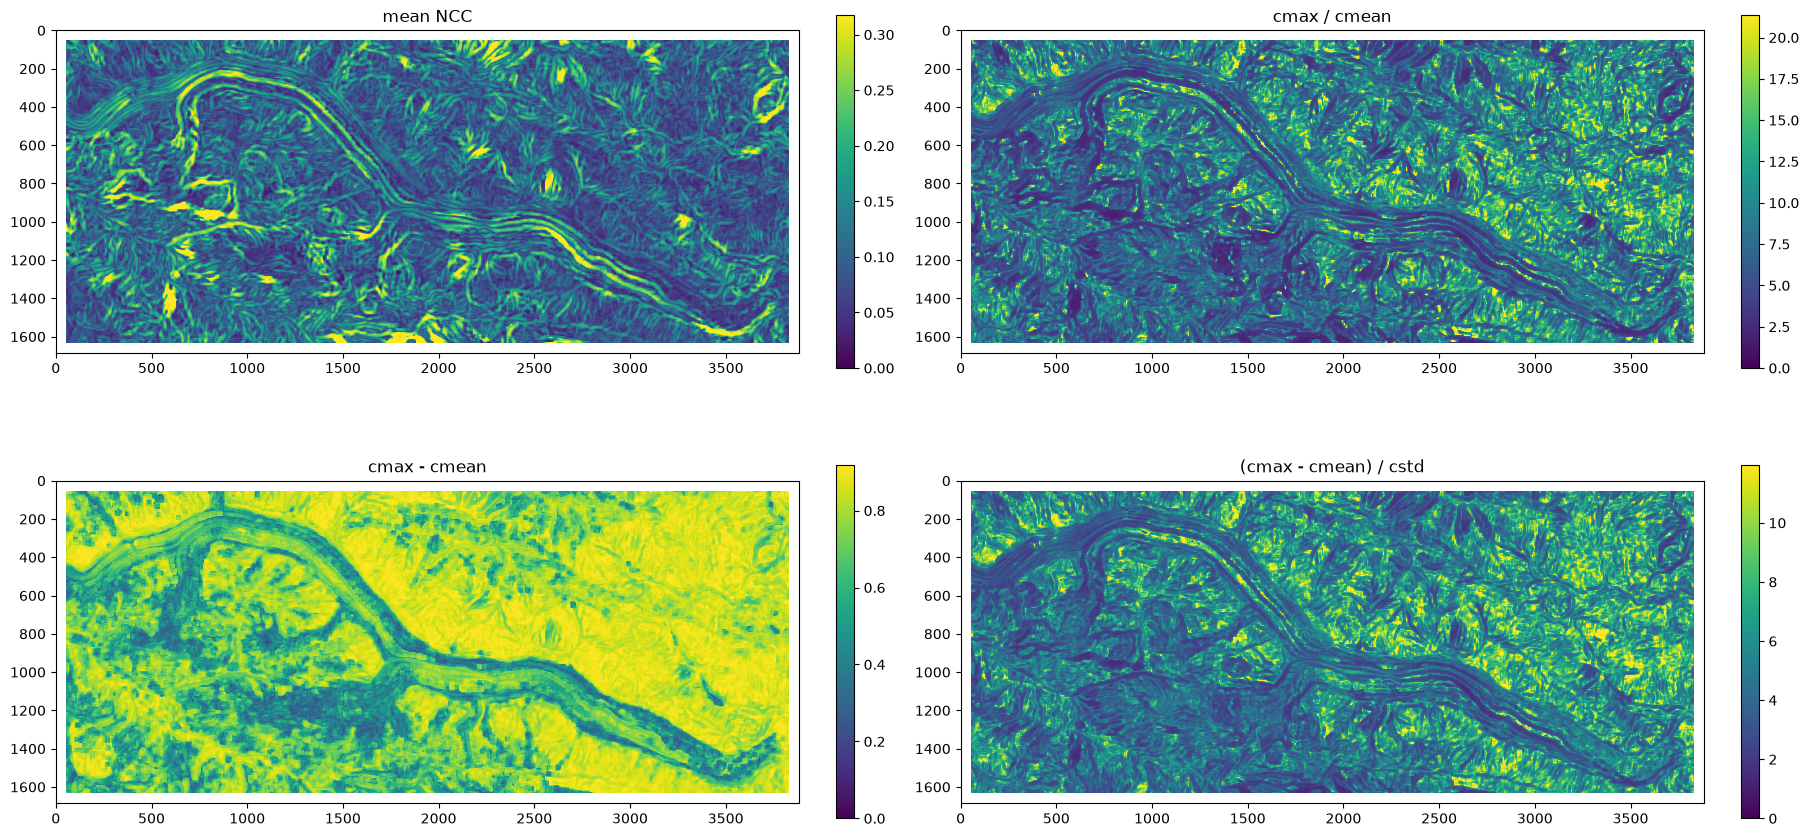

In [7]:
quality_metrics = [
    (cmean, "mean NCC"),
    (peak_ratio, "cmax / cmean"),
    (peak_margin, "cmax - cmean"),
    (peak_prominence, "(cmax - cmean) / cstd"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 9), constrained_layout=True)
for ax, (metric, title) in zip(axes.flat, quality_metrics):
    finite = metric[np.isfinite(metric)]
    vmax = np.percentile(finite, 99)
    image = ax.imshow(metric, cmap="viridis", vmin=0, vmax=vmax, interpolation="none")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, shrink=0.8)
plt.show()

## Filter by forward/backward consistency $e_{fb}$

Reload the two relevant products, keep matches whose closure error is at most each threshold, and write four filtered magnitude rasters. Non-finite closure errors are rejected explicitly.

In [8]:
with gdal.Open(str(DATA_DIR / "Sentinel2_rho.tif"), gdal.GA_ReadOnly) as ds:
    rho_from_disk = ds.ReadAsArray()

with gdal.Open(str(DATA_DIR / "Sentinel2_efb.tif"), gdal.GA_ReadOnly) as ds:
    efb_from_disk = ds.ReadAsArray()

thresholds = [0, 1, np.sqrt(2)]
rho_filtered = {}

for threshold in thresholds:
    rho_fb = rho_from_disk.copy()
    reject = ~np.isfinite(efb_from_disk) | (efb_from_disk > threshold)
    rho_fb[reject] = np.nan
    rho_filtered[threshold] = rho_fb
    writetiff(
        DATA_DIR / f"Sentinel2_rho_efb{threshold:.2f}.tif",
        rho_fb,
        nodata=np.nan,
    )

## Compare the filtered displacement magnitudes

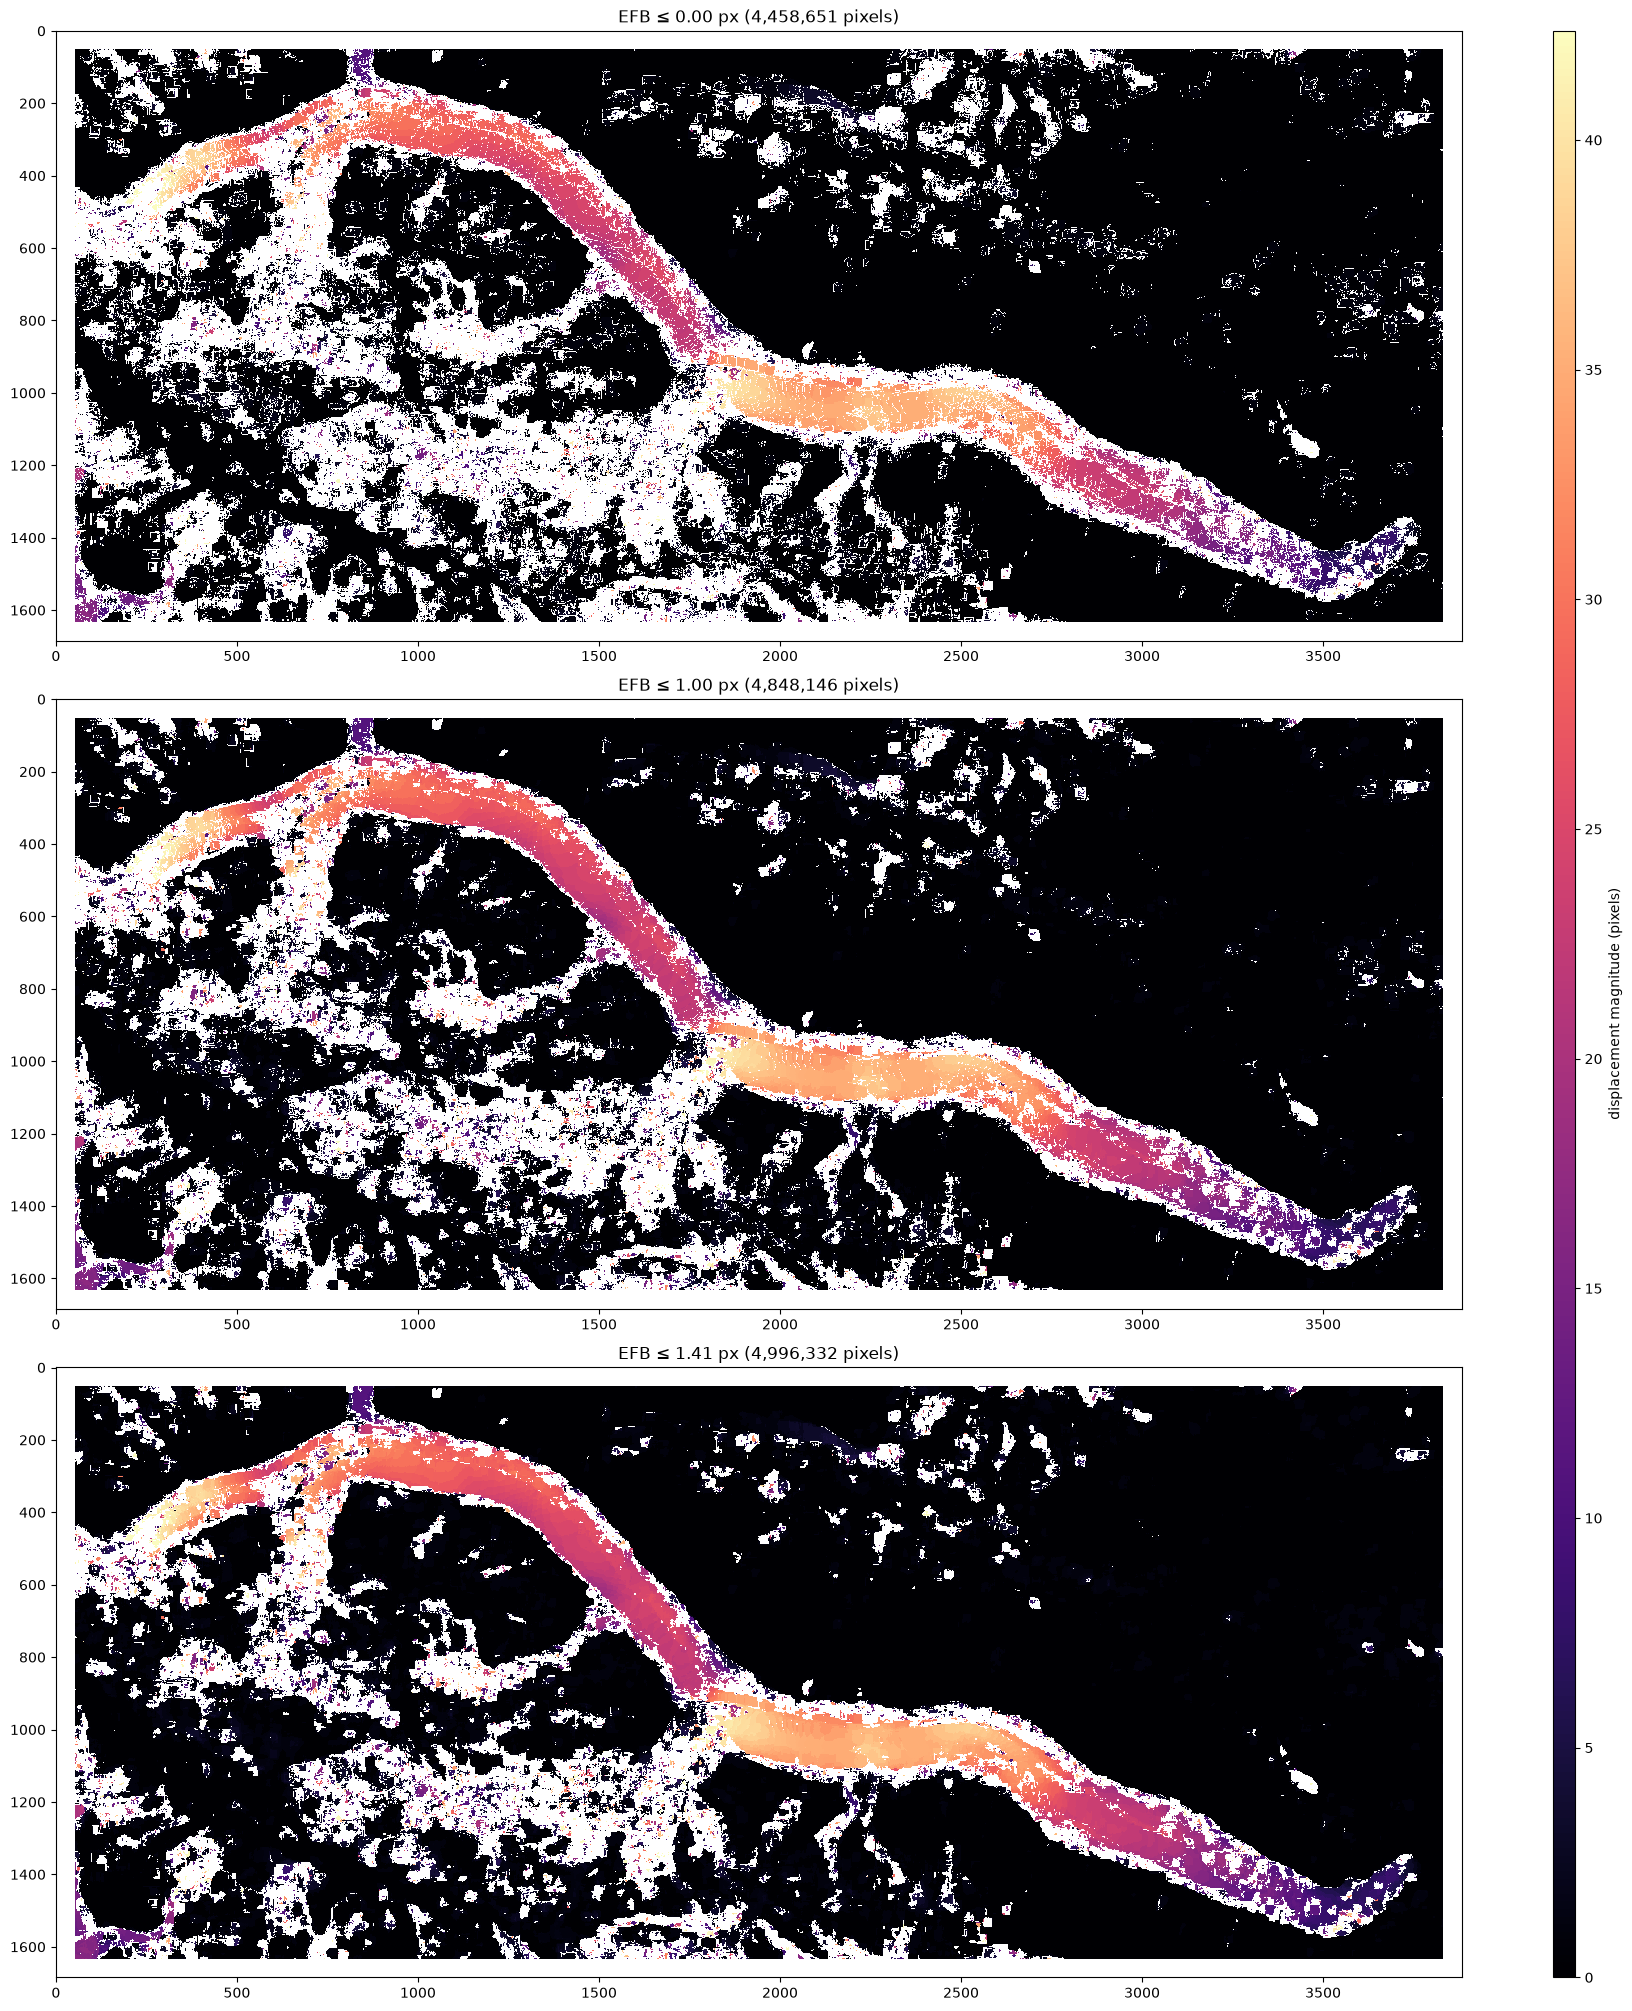

In [9]:
finite_rho = rho_from_disk[np.isfinite(rho_from_disk)]
vmax = np.nanpercentile(finite_rho, 98)

fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
last_image = None
for ax, threshold in zip(axes, thresholds):
    image = ax.imshow(
        rho_filtered[threshold], cmap="magma", vmin=0, vmax=vmax, interpolation="none"
    )
    last_image = image
    retained = np.count_nonzero(np.isfinite(rho_filtered[threshold]))
    ax.set_title(f"EFB ≤ {threshold:.2f} px ({retained:,} pixels)")

fig.colorbar(last_image, ax=axes, label="displacement magnitude (pixels)", aspect=90)
plt.show()

### Compare NCC distributions by $e_{fb}$ class

Compare moving matches (rho > 0) that are strongly forward/backward consistent (EFB ≤ √2) with inconsistent matches (EFB > √2). Each histogram is normalized independently, and its display range is limited to the combined 1th–99th percentiles so a small number of extreme ratios do not dominate the axes.

This comparison tests whether the NCC metrics distinguish groups defined by EFB. It does not establish correctness by itself because EFB is a consistency measure rather than ground truth.

EFB ≤ √2 moving pixels: 1,391,190
EFB > √2 moving pixels: 948,122
cmax / cmean                EFB ≤ √2 : p10=3.865, median=6.840, p90=11.938
cmax / cmean                EFB > √2 : p10=3.213, median=5.355, p90=8.667
(cmax - cmean) / cstd       EFB ≤ √2 : p10=2.742, median=4.342, p90=7.032
(cmax - cmean) / cstd       EFB > √2 : p10=2.400, median=3.429, p90=4.875


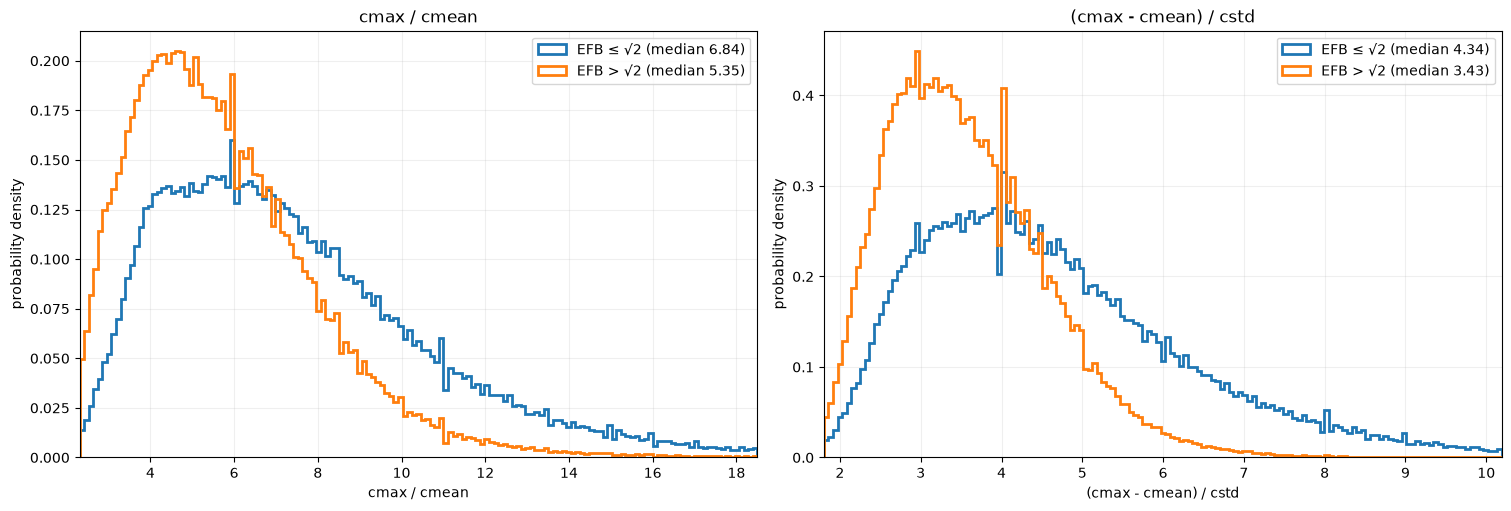

In [11]:
moving = np.isfinite(rho) & (rho > 0) & np.isfinite(efb)
low_efb = moving & (efb2 <= 2)
high_efb = moving & (efb2 > 2)

print(f"EFB ≤ √2 moving pixels: {np.count_nonzero(low_efb):,}")
print(f"EFB > √2 moving pixels: {np.count_nonzero(high_efb):,}")

metrics_for_comparison = {
    "cmax / cmean": peak_ratio,
    "(cmax - cmean) / cstd": peak_prominence,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for ax, (label, metric) in zip(axes, metrics_for_comparison.items()):
    consistent = metric[low_efb]
    inconsistent = metric[high_efb]
    consistent = consistent[np.isfinite(consistent)]
    inconsistent = inconsistent[np.isfinite(inconsistent)]

    lower = min(np.percentile(consistent, 1), np.percentile(inconsistent, 1))
    upper = max(np.percentile(consistent, 99), np.percentile(inconsistent, 99))
    bins = np.linspace(lower, upper, 150)

    for values, group_label, color in (
        (consistent, "EFB ≤ √2", "tab:blue"),
        (inconsistent, "EFB > √2", "tab:orange"),
    ):
        median = np.median(values)
        p10, p90 = np.percentile(values, [10, 90])
        print(
            f"{label:27s} {group_label:9s}: "
            f"p10={p10:.3f}, median={median:.3f}, p90={p90:.3f}"
        )
        ax.hist(
            values, bins=bins, density=True, histtype="step",
            linewidth=2, color=color, label=f"{group_label} (median {median:.2f})"
        )

    ax.set_xlim(lower, upper)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("probability density")
    ax.legend()
    ax.grid(alpha=0.2)

plt.show()

### Retention curves for NCC thresholds

For each possible NCC threshold, the curves below show the percentage of each EFB group that would survive. Moving right applies a stricter threshold. A useful secondary metric retains a large fraction of the EFB ≤ √2 group while rejecting much of the EFB > √2 group, producing a wide vertical gap between the curves.

The marked threshold maximizes that retention gap over the displayed range. It is a descriptive operating point, not an automatically validated quality threshold: the EFB classes are still proxies for consistency rather than ground-truth labels.

cmax / cmean: largest retention gap at 6.803 — keep 50.5% of EFB ≤ √2 and 27.0% of EFB > √2
(cmax - cmean) / cstd: largest retention gap at 4.355 — keep 49.7% of EFB ≤ √2 and 20.0% of EFB > √2


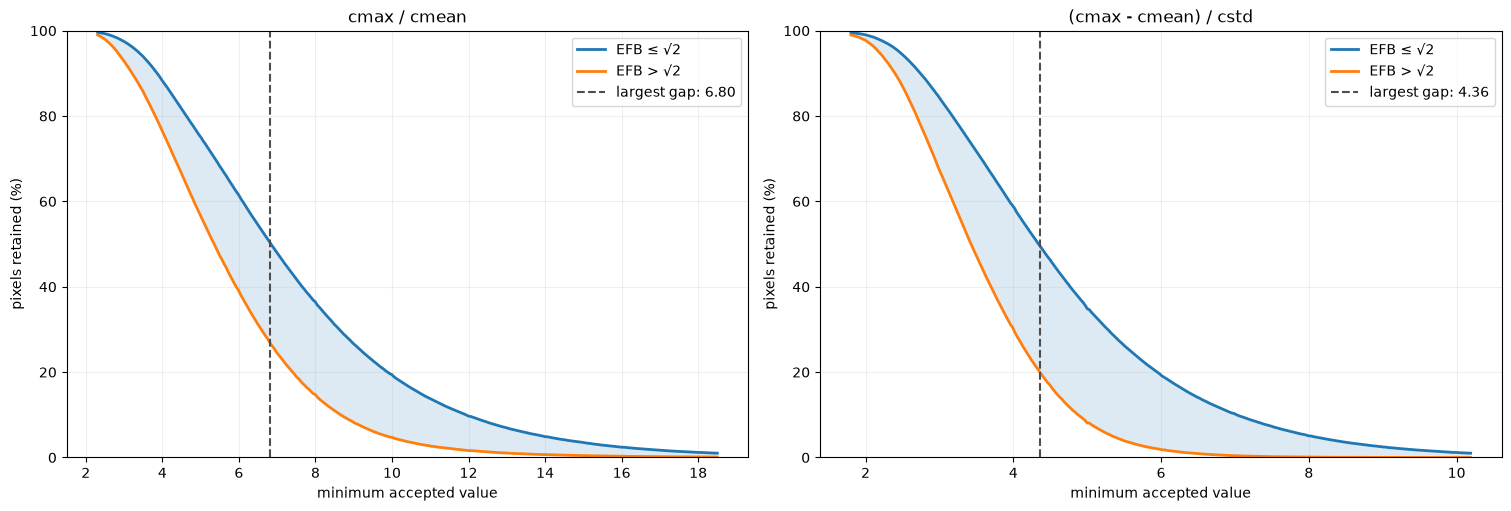

In [12]:
moving = np.isfinite(rho) & (rho > 0) & np.isfinite(efb)
low_efb = moving & (efb2 <= 2)
high_efb = moving & (efb2 > 2)

retention_metrics = {
    "cmax / cmean": peak_ratio,
    "(cmax - cmean) / cstd": peak_prominence,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for ax, (label, metric) in zip(axes, retention_metrics.items()):
    consistent = metric[low_efb]
    inconsistent = metric[high_efb]
    consistent = np.sort(consistent[np.isfinite(consistent)])
    inconsistent = np.sort(inconsistent[np.isfinite(inconsistent)])

    lower = min(np.percentile(consistent, 1), np.percentile(inconsistent, 1))
    upper = max(np.percentile(consistent, 99), np.percentile(inconsistent, 99))
    thresholds = np.linspace(lower, upper, 300)

    consistent_retained = 100.0 * (
        1.0 - np.searchsorted(consistent, thresholds, side="left") / consistent.size
    )
    inconsistent_retained = 100.0 * (
        1.0 - np.searchsorted(inconsistent, thresholds, side="left") / inconsistent.size
    )
    retention_gap = consistent_retained - inconsistent_retained
    best_index = np.argmax(retention_gap)
    best_threshold = thresholds[best_index]

    print(
        f"{label}: largest retention gap at {best_threshold:.3f} — "
        f"keep {consistent_retained[best_index]:.1f}% of EFB ≤ √2 and "
        f"{inconsistent_retained[best_index]:.1f}% of EFB > √2"
    )

    ax.plot(thresholds, consistent_retained, linewidth=2, label="EFB ≤ √2")
    ax.plot(thresholds, inconsistent_retained, linewidth=2, label="EFB > √2")
    ax.fill_between(
        thresholds, inconsistent_retained, consistent_retained,
        where=consistent_retained >= inconsistent_retained, alpha=0.15
    )
    ax.axvline(
        best_threshold, color="0.3", linestyle="--", linewidth=1.5,
        label=f"largest gap: {best_threshold:.2f}"
    )
    ax.set_title(label)
    ax.set_xlabel("minimum accepted value")
    ax.set_ylabel("pixels retained (%)")
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(alpha=0.2)

plt.show()

Both correlation metrics are associated with EFB consistency, but peak prominence provides better separation. At roughly 50% retention of pixels with EFB ≤ √2, it keeps only 20% of pixels with EFB > √2, compared with 27% for cmax / cmean. Thus, peak prominence is the stronger secondary quality filter for this dataset.